In [22]:
# =====================================
# Cell 1 – Imports & Global Config
# =====================================
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# -------------------------
# Paths & Data Config
# -------------------------
DATASET_PATH = "/kaggle/working/nilm_dataset_part1.csv"

APPLIANCES = [
    'TV-LG', 'MacBookPro2011-2', 'TV-Philips', 'Fridge-Freezer',
    'CoffeeMachine', 'Freezer', 'TV-Sharp', 'Kettle', 'MacBook2007'
]

# শুধু Active_Power_W চ্যানেল ব্যবহার করছি
MAINS_COLS = ['Active_Power_W']

WINDOW_SIZE = 100      # প্রতি window length
STRIDE = 50            # step
OPM_THRESHOLD = 0.5    # power range threshold (অনেক ছোট রেখেছি)

RUN_CLASSICAL_ML = True
RUN_RESNET = True

MAX_WINDOWS = 40000    # নিরাপদ limit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [23]:
# =====================================
# Cell 2 – Metrics helper
# =====================================
def compute_classification_metrics(y_true, y_pred):
    """
    Global summary metrics: accuracy, macro/weighted precision/recall/F1
    """
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision_macro": prec_macro,
        "recall_macro": rec_macro,
        "f1_macro": f1_macro,
        "precision_weighted": prec_weighted,
        "recall_weighted": rec_weighted,
        "f1_weighted": f1_weighted
    }


def print_per_class_report(y_true, y_pred):
    """
    প্রতি class এর precision/recall/F1 print করার জন্য ছোট helper
    """
    prec, rec, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    n_classes = len(prec)
    print("Per-class metrics:")
    print("class\tcount\tprec\trecall\tF1")
    for c in range(n_classes):
        print(f"{c}\t{support[c]}\t{prec[c]:.3f}\t{rec[c]:.3f}\t{f1[c]:.3f}")


In [24]:
# =====================================
# Cell 3 – Load dataframe
# =====================================
def load_base_dataframe(path):
    print(f"Loading NILM dataframe from: {path}")
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    print("Shape:", df.shape)
    return df

df_check = load_base_dataframe(DATASET_PATH)
display(df_check.head())


Loading NILM dataframe from: /kaggle/working/nilm_dataset_part1.csv
Shape: (8297354, 10)


,TV-LG_Status,MacBookPro2011-2_Status,TV-Philips_Status,Fridge-Freezer_Status,CoffeeMachine_Status,Freezer_Status,TV-Sharp_Status,Kettle_Status,MacBook2007_Status,Active_Power_W
2016-10-05 23:10:01,0,0,0,0,0,1,0,0,0,1.0
2016-10-05 23:10:02,0,0,0,0,0,0,0,0,0,0.0
2016-10-05 23:10:03,0,0,0,0,0,0,0,0,0,0.0
2016-10-05 23:10:04,0,0,0,0,0,0,0,0,0,0.0
2016-10-05 23:10:05,0,0,0,0,0,0,0,0,0,0.0


In [25]:
# =====================================
# Cell 4 – Window builder + classical features
# =====================================
def build_windows_and_labels(
    df,
    appliances,
    window_size=100,
    stride=50,
    threshold=0.5
):
    """
    df: NILM dataframe (Active_Power_W + *_Status)
    output:
      X: (N, 1, L)  raw Active_Power_W windows
      y: (N,)       multiclass label (combo id)
      combo_mapping: dict  combo -> class id
    """
    status_cols = [f"{name}_Status" for name in appliances]

    # Missing status cols থাকলে 0 দিয়ে তৈরি করি
    for col in status_cols:
        if col not in df.columns:
            df[col] = 0

    X_list = []
    y_multi_list = []

    active_power = df["Active_Power_W"].values

    indices = range(0, len(df) - window_size, stride)

    for start in indices:
        end = start + window_size
        window = df.iloc[start:end]

        pw = active_power[start:end]
        power_range = pw.max() - pw.min()

        # OPM-style filter
        if power_range < threshold:
            continue

        # single-channel mains window
        mains_window = window[MAINS_COLS].values.T  # (1, L)
        X_list.append(mains_window.astype(np.float32))

        # multi-label ON/OFF → combination vector
        labels = []
        for col in status_cols:
            labels.append(int(window[col].max() > 0))
        y_multi_list.append(labels)

    if not X_list:
        print("WARNING: No windows selected!")
        return None, None, None

    X = np.stack(X_list, axis=0)          # (N, 1, L)
    y_multi = np.array(y_multi_list)      # (N, n_appliances)

    # subsample যদি খুব বড় হয়
    if len(X) > MAX_WINDOWS:
        idx = np.random.choice(len(X), MAX_WINDOWS, replace=False)
        X = X[idx]
        y_multi = y_multi[idx]

    print(f"Windows selected: {len(X)}")

    # combo → class id mapping
    combo_dict = {}
    next_id = 0
    y_class = []

    for row in y_multi:
        key = tuple(row.tolist())
        if key not in combo_dict:
            combo_dict[key] = next_id
            next_id += 1
        y_class.append(combo_dict[key])

    y_class = np.array(y_class, dtype=np.int64)
    print(f"Unique combinations (classes): {next_id}")

    return X, y_class, combo_dict


def extract_classical_features(X_raw):
    """
    X_raw: (N, C, L)
    প্রতি channel: mean, std, min, max, range → 5*C features
    """
    N, C, L = X_raw.shape
    feats = []
    for i in range(N):
        f = []
        for ch in range(C):
            v = X_raw[i, ch, :]
            f.append(v.mean())
            f.append(v.std())
            f.append(v.min())
            f.append(v.max())
            f.append(v.max() - v.min())
        feats.append(f)
    return np.array(feats, dtype=np.float32)


In [26]:
# =====================================
# Cell 5 – Classical ML models
# =====================================
def run_classical_ml_models(X, y_class):
    """
    Returns:
      results: list of metrics dict per model
      eval_info: ExtraTrees evaluation dict (y_true, y_pred, y_proba)
    """
    results = []
    eval_info = None

    # stratify=None রাখছি যাতে rare class problem না আসে
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=None
    )

    models = [
        ("CART", DecisionTreeClassifier(random_state=42)),
        ("KNN_euclidean", KNeighborsClassifier(metric='euclidean')),
        ("LDA", LinearDiscriminantAnalysis()),
        ("GaussianNB", GaussianNB()),
        ("RandomForest", RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1)),
        ("ExtraTrees", ExtraTreesClassifier(
            n_estimators=100, random_state=42, n_jobs=-1))
    ]

    print("Running classical ML models...")
    for name, clf in models:
        print(f"  -> {name}")
        t0 = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - t0

        t1 = time.time()
        y_pred = clf.predict(X_test)
        predict_time = time.time() - t1

        metrics = compute_classification_metrics(y_train if False else y_test, y_pred)

        res = {
            "model": name,
            "train_time": train_time,
            "predict_time": predict_time,
        }
        res.update(metrics)
        results.append(res)

        if name == "ExtraTrees":
            if hasattr(clf, "predict_proba"):
                y_proba = clf.predict_proba(X_test)
            else:
                n_classes = len(np.unique(y_train))
                y_proba = np.eye(n_classes)[y_pred]
            eval_info = {
                "model": name,
                "y_true": y_test,
                "y_pred": y_pred,
                "y_proba": y_proba
            }

    return results, eval_info


In [27]:
# =====================================
# Cell 6 – ResNet-50 1D definition
# =====================================
class Bottleneck1D(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv1d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm1d(planes)

        self.conv2 = nn.Conv1d(
            planes, planes, kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(planes)

        self.conv3 = nn.Conv1d(
            planes, planes * self.expansion, kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm1d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, block, layers, input_channels=1, num_outputs=10):
        super().__init__()
        self.inplanes = 64

        self.conv1 = nn.Conv1d(
            input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(512 * block.expansion, num_outputs)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv1d(
                    self.inplanes, planes * block.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm1d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        out = self.fc(x)
        return out


def resnet50_1d(num_outputs, input_channels=1):
    return ResNet1D(
        Bottleneck1D, [3, 4, 6, 3],
        input_channels=input_channels,
        num_outputs=num_outputs
    )


In [28]:
# =====================================
# Cell 7 – Train ResNet + run experiment
# =====================================
def train_resnet_for_config(
    X,
    y_class,
    n_epochs=8,
    batch_size=256,
    lr=1e-3
):
    print(f"Training ResNet-50 (multiclass) on {len(X)} windows")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=None
    )

    X_train_t = torch.from_numpy(X_train).float().to(device)
    X_test_t = torch.from_numpy(X_test).float().to(device)
    y_train_t = torch.from_numpy(y_train).long().to(device)
    y_test_t = torch.from_numpy(y_test).long().to(device)

    num_outputs = int(np.max(y_class)) + 1
    model = resnet50_1d(num_outputs=num_outputs, input_channels=X.shape[1]).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_dataset = TensorDataset(X_train_t, y_train_t)
    test_dataset = TensorDataset(X_test_t, y_test_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # ---- Train loop ----
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        for bx, by in train_loader:
            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{n_epochs}] Loss: {running_loss/len(train_loader):.4f}")
    train_time = time.time() - t0

    # ---- Eval ----
    t1 = time.time()
    model.eval()
    all_logits = []
    all_labels = []

    with torch.no_grad():
        for bx, by in test_loader:
            logits = model(bx)
            all_logits.append(logits.cpu().numpy())
            all_labels.append(by.cpu().numpy())
    predict_time = time.time() - t1

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # softmax
    logits_max = all_logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(all_logits - logits_max)
    y_proba = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    y_pred = np.argmax(y_proba, axis=1)
    y_true = all_labels

    metrics = compute_classification_metrics(y_true, y_pred)
    res = {
        "model": "ResNet50_1D",
        "train_time": train_time,
        "predict_time": predict_time,
    }
    res.update(metrics)

    eval_info = {
        "model": "ResNet50_1D",
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    return res, model, eval_info


def run_single_experiment():
    df = load_base_dataframe(DATASET_PATH)

    # windows + labels
    X_raw, y_class, combo_map = build_windows_and_labels(
        df,
        APPLIANCES,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        threshold=OPM_THRESHOLD
    )

    if X_raw is None:
        raise RuntimeError("No windows found – try lowering OPM_THRESHOLD.")

    print("X_raw shape:", X_raw.shape)

    results = []

    # Classical ML
    ml_eval = None
    if RUN_CLASSICAL_ML:
        X_feats = extract_classical_features(X_raw)
        print("Classical feature shape:", X_feats.shape)
        ml_results, ml_eval = run_classical_ml_models(X_feats, y_class)
        results.extend(ml_results)

    # ResNet
    resnet_eval = None
    resnet_model = None
    if RUN_RESNET:
        res_resnet, resnet_model, resnet_eval = train_resnet_for_config(
            X_raw, y_class, n_epochs=8, batch_size=256, lr=1e-3
        )
        results.append(res_resnet)

    results_df = pd.DataFrame(results)
    print("\n=== Results Table ===")
    display(results_df)

    return results_df, X_raw, y_class, ml_eval, resnet_eval, resnet_model


# ---- Run it once ----
results_df, X_windows, y_classes, ml_eval, resnet_eval, resnet_model = run_single_experiment()


Loading NILM dataframe from: /kaggle/working/nilm_dataset_part1.csv
Shape: (8297354, 10)
Windows selected: 17293
Unique combinations (classes): 46
X_raw shape: (17293, 1, 100)
Classical feature shape: (17293, 5)
Running classical ML models...
  -> CART
  -> KNN_euclidean
  -> LDA
  -> GaussianNB
  -> RandomForest
  -> ExtraTrees
Training ResNet-50 (multiclass) on 17293 windows
Epoch [1/8] Loss: 1.6461
Epoch [2/8] Loss: 1.3550
Epoch [3/8] Loss: 1.2966
Epoch [4/8] Loss: 1.2990
Epoch [5/8] Loss: 1.3162
Epoch [6/8] Loss: 1.2773
Epoch [7/8] Loss: 1.2761
Epoch [8/8] Loss: 1.2729

=== Results Table ===


,model,train_time,predict_time,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,CART,0.002881,0.000486,0.645562,0.028175,0.053372,0.035895,0.428801,0.645562,0.514589
1,KNN_euclidean,0.009788,0.379474,0.645562,0.028175,0.053372,0.035895,0.428801,0.645562,0.514589
2,LDA,0.017242,0.001043,0.644117,0.027357,0.088235,0.036859,0.427224,0.644117,0.512447
3,GaussianNB,0.007252,0.013578,0.637178,0.033522,0.121212,0.045355,0.425730,0.637178,0.509926
4,RandomForest,0.284224,0.065075,0.645562,0.028175,0.053372,0.035895,0.428801,0.645562,0.514589
5,ExtraTrees,0.220728,0.065398,0.645562,0.028175,0.053372,0.035895,0.428801,0.645562,0.514589
6,ResNet50_1D,81.413251,0.404801,0.636600,0.058264,0.066299,0.052628,0.455500,0.636600,0.520998


ExtraTrees – global metrics already in table above
ExtraTrees – per-class report:
Per-class metrics:
class	count	prec	recall	F1
0	2197	0.670	1.000	0.802
1	377	0.000	0.000	0.000
2	2	0.000	0.000	0.000
3	55	0.203	0.655	0.310
4	67	0.000	0.000	0.000
5	8	0.000	0.000	0.000
6	24	0.000	0.000	0.000
7	344	0.000	0.000	0.000
8	164	0.000	0.000	0.000
9	21	0.000	0.000	0.000
10	27	0.000	0.000	0.000
11	5	0.000	0.000	0.000
12	30	0.000	0.000	0.000
13	1	0.000	0.000	0.000
14	80	0.000	0.000	0.000
15	1	0.000	0.000	0.000
16	5	0.000	0.000	0.000
17	8	0.000	0.000	0.000
18	1	0.000	0.000	0.000
19	1	0.000	0.000	0.000
20	3	0.000	0.000	0.000
21	26	0.000	0.000	0.000
22	3	0.000	0.000	0.000
23	1	0.000	0.000	0.000
24	2	0.000	0.000	0.000
25	1	0.000	0.000	0.000
26	1	0.000	0.000	0.000
27	1	0.000	0.000	0.000
28	1	0.000	0.000	0.000
29	1	0.000	0.000	0.000
30	1	0.000	0.000	0.000
ExtraTrees Confusion Matrix:


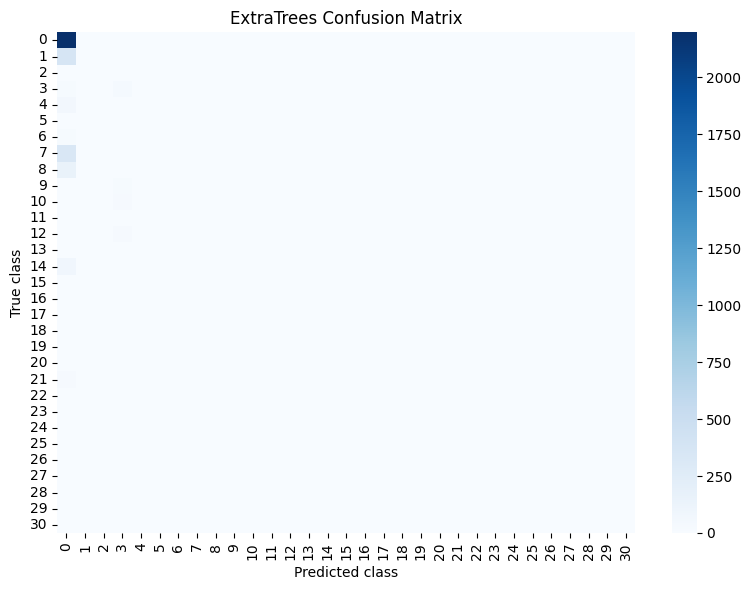

ExtraTrees ROC Curves (first few classes):


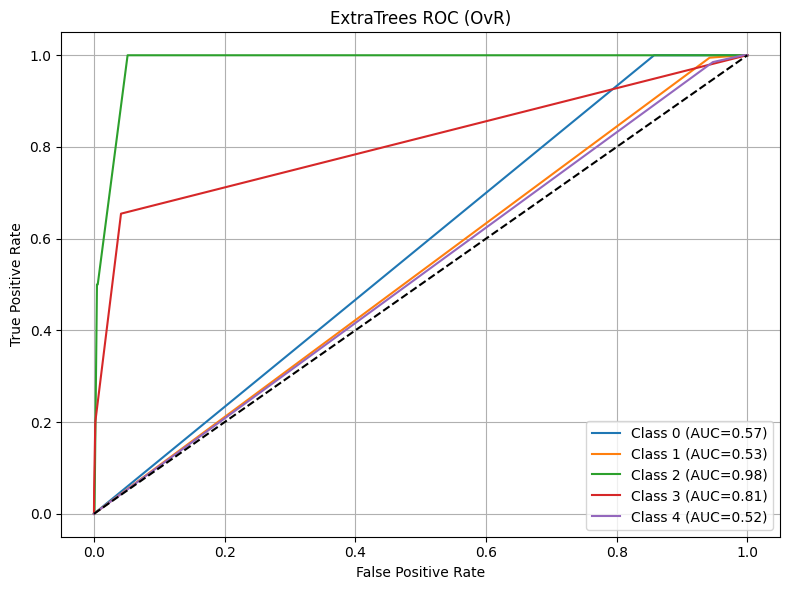


ResNet-50 – per-class report:
Per-class metrics:
class	count	prec	recall	F1
0	2197	0.671	0.980	0.797
1	377	0.000	0.000	0.000
2	2	0.000	0.000	0.000
3	55	0.647	0.200	0.306
4	67	0.000	0.000	0.000
5	8	0.000	0.000	0.000
6	24	0.000	0.000	0.000
7	344	0.163	0.038	0.061
8	164	0.000	0.000	0.000
9	21	0.000	0.000	0.000
10	27	0.128	0.370	0.190
11	5	0.000	0.000	0.000
12	30	0.197	0.467	0.277
13	1	0.000	0.000	0.000
14	80	0.000	0.000	0.000
15	1	0.000	0.000	0.000
16	5	0.000	0.000	0.000
17	8	0.000	0.000	0.000
18	1	0.000	0.000	0.000
19	1	0.000	0.000	0.000
20	3	0.000	0.000	0.000
21	26	0.000	0.000	0.000
22	3	0.000	0.000	0.000
23	1	0.000	0.000	0.000
24	2	0.000	0.000	0.000
25	1	0.000	0.000	0.000
26	1	0.000	0.000	0.000
27	1	0.000	0.000	0.000
28	1	0.000	0.000	0.000
29	1	0.000	0.000	0.000
30	1	0.000	0.000	0.000
ResNet-50 Confusion Matrix:


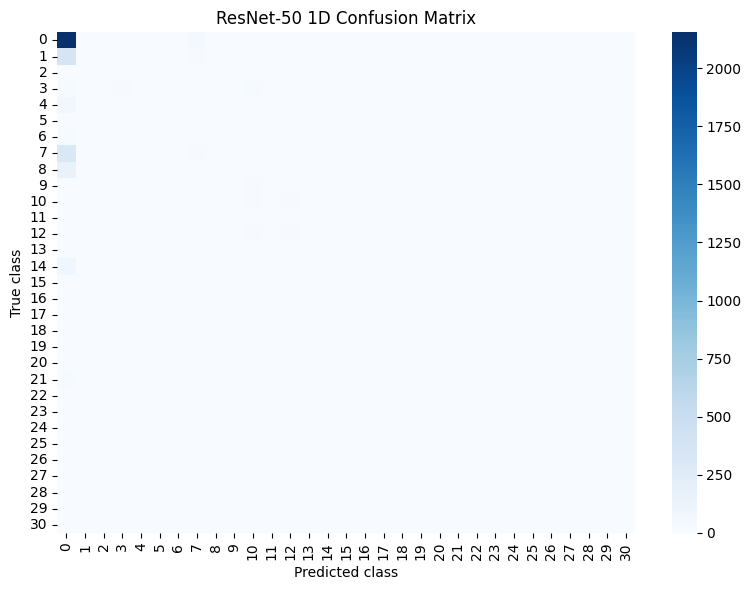

ResNet-50 ROC Curves (first few classes):


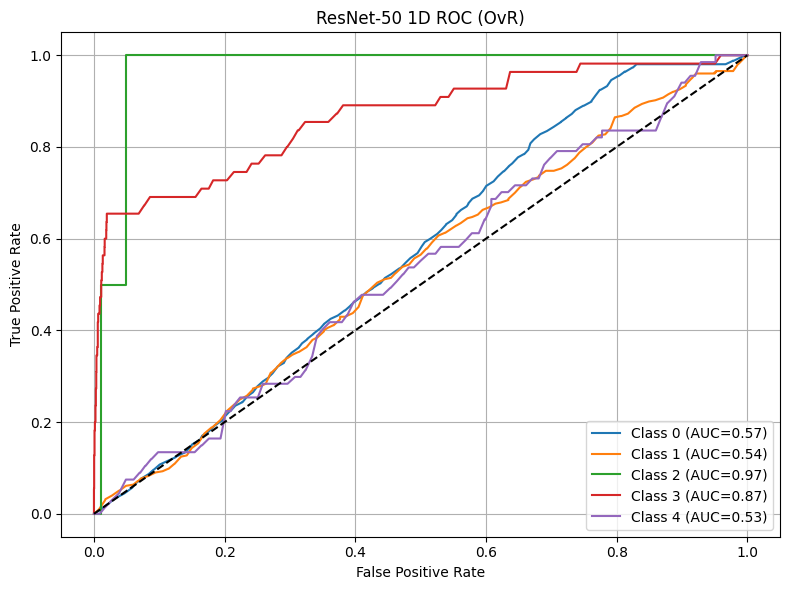

In [29]:
# =====================================
# Cell 8 – Confusion Matrix + ROC curves
# =====================================
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.tight_layout()
    plt.show()


def plot_multiclass_roc(y_true, y_proba, title, max_classes=5):
    n_classes = y_proba.shape[1]
    classes_to_plot = min(n_classes, max_classes)

    y_bin = label_binarize(y_true, classes=np.arange(n_classes))

    plt.figure(figsize=(8, 6))
    for c in range(classes_to_plot):
        fpr, tpr, _ = roc_curve(y_bin[:, c], y_proba[:, c])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {c} (AUC={roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ----- ExtraTrees -----
if ml_eval is not None:
    print("ExtraTrees – global metrics already in table above")
    print("ExtraTrees – per-class report:")
    print_per_class_report(ml_eval["y_true"], ml_eval["y_pred"])

    print("ExtraTrees Confusion Matrix:")
    plot_confusion_matrix(ml_eval["y_true"], ml_eval["y_pred"],
                          "ExtraTrees Confusion Matrix")

    print("ExtraTrees ROC Curves (first few classes):")
    plot_multiclass_roc(ml_eval["y_true"], ml_eval["y_proba"],
                        "ExtraTrees ROC (OvR)")

# ----- ResNet -----
if resnet_eval is not None:
    print("\nResNet-50 – per-class report:")
    print_per_class_report(resnet_eval["y_true"], resnet_eval["y_pred"])

    print("ResNet-50 Confusion Matrix:")
    plot_confusion_matrix(resnet_eval["y_true"], resnet_eval["y_pred"],
                          "ResNet-50 1D Confusion Matrix")

    print("ResNet-50 ROC Curves (first few classes):")
    plot_multiclass_roc(resnet_eval["y_true"], resnet_eval["y_proba"],
                        "ResNet-50 1D ROC (OvR)")


Loading NILM dataframe from: /kaggle/working/nilm_dataset_part1.csv
Shape: (8297354, 10)


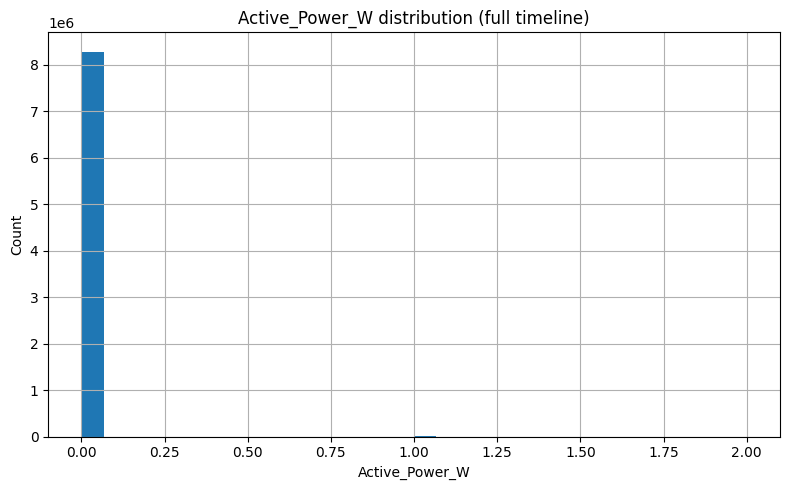

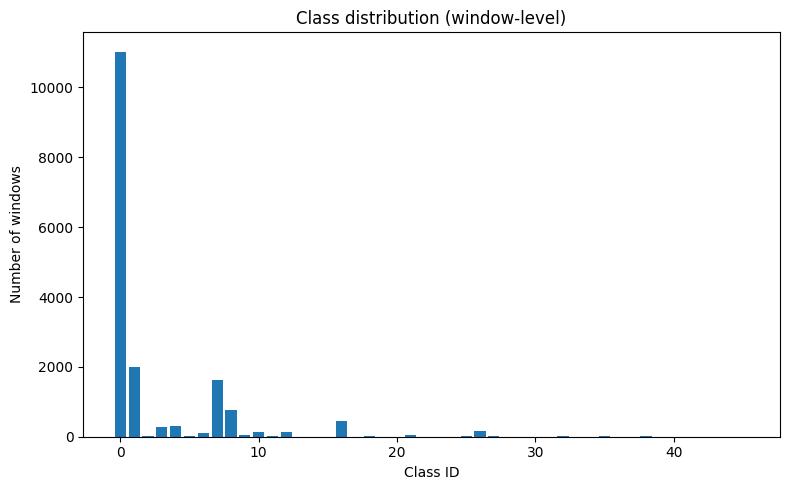

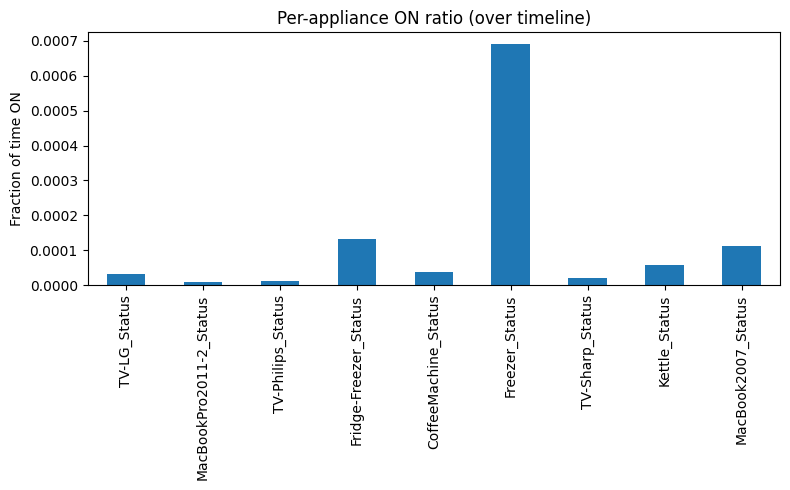

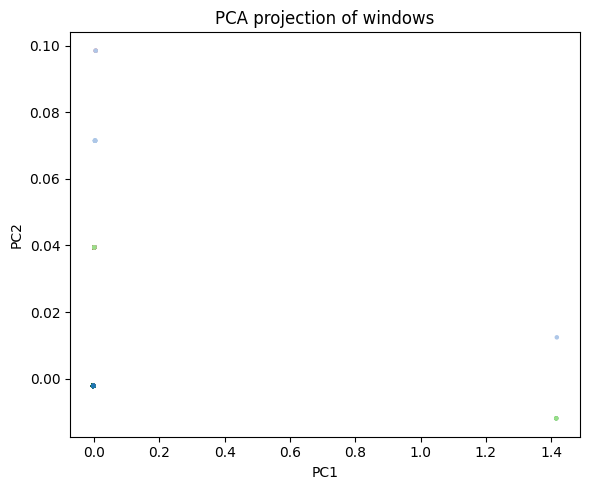

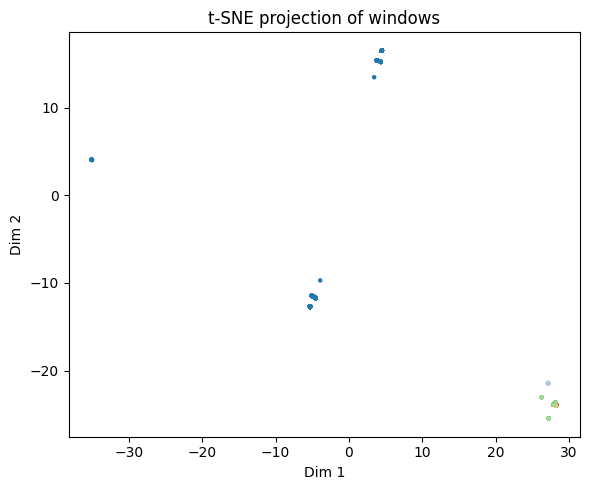

In [30]:
# =====================================
# Cell 9 – Simple EDA (hist, class dist, PCA, t-SNE)
# =====================================
df_full = load_base_dataframe(DATASET_PATH)

# 1) Active_Power_W histogram
plt.figure(figsize=(8, 5))
df_full["Active_Power_W"].hist(bins=30)
plt.title("Active_Power_W distribution (full timeline)")
plt.xlabel("Active_Power_W")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) class distribution (window labels)
unique, counts = np.unique(y_classes, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts)
plt.title("Class distribution (window-level)")
plt.xlabel("Class ID")
plt.ylabel("Number of windows")
plt.tight_layout()
plt.show()

# 3) Per-appliance ON ratio
status_cols = [f"{name}_Status" for name in APPLIANCES if f"{name}_Status" in df_full.columns]
on_ratios = df_full[status_cols].mean()

plt.figure(figsize=(8, 5))
on_ratios.plot(kind="bar")
plt.title("Per-appliance ON ratio (over timeline)")
plt.ylabel("Fraction of time ON")
plt.tight_layout()
plt.show()

# 4) PCA + t-SNE on classical features (subset)
X_feats_all = extract_classical_features(X_windows)
N = len(X_feats_all)
max_points = min(2000, N)
idx = np.random.choice(N, max_points, replace=False)

X_sub = X_feats_all[idx]
y_sub = y_classes[idx]

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sub)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, c=y_sub, cmap="tab20")
plt.title("PCA projection of windows")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# t-SNE 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30,
            init="random", learning_rate="auto")
X_tsne = tsne.fit_transform(X_sub)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=5, c=y_sub, cmap="tab20")
plt.title("t-SNE projection of windows")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.tight_layout()
plt.show()


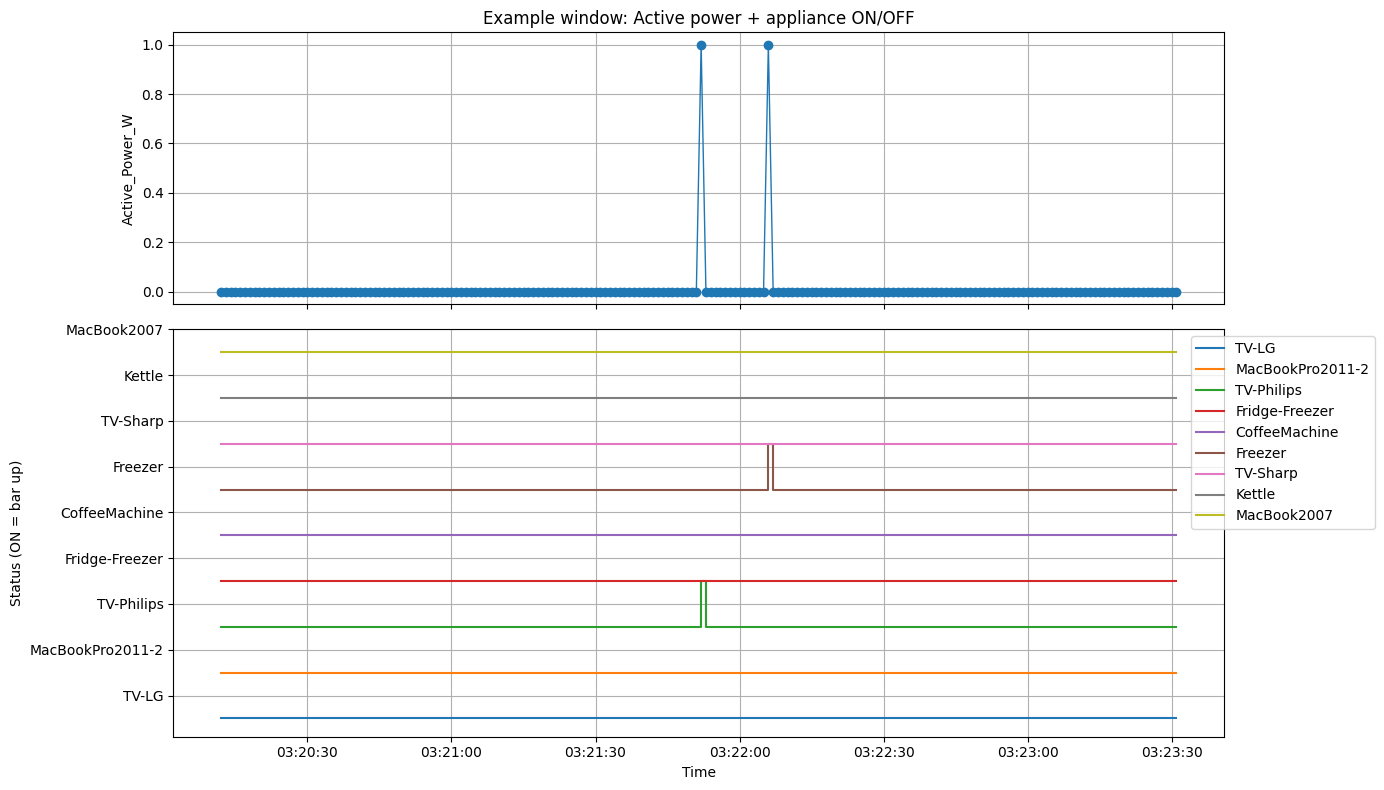

In [31]:
# =====================================
# Cell 10 – Example window plot (Active power + statuses)
# =====================================
WINDOW_PLOT_SIZE = 200

any_on = df_full[[f"{a}_Status" for a in APPLIANCES]].sum(axis=1) > 0
if not any_on.any():
    print("No ON windows found!")
else:
    idx_on = np.where(any_on.values)[0]
    center_idx = idx_on[len(idx_on) // 2]

    start_idx = max(0, center_idx - WINDOW_PLOT_SIZE // 2)
    end_idx = min(len(df_full), start_idx + WINDOW_PLOT_SIZE)

    window = df_full.iloc[start_idx:end_idx]
    time_axis = window.index

    status_cols = [f"{a}_Status" for a in APPLIANCES if f"{a}_Status" in window.columns]

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2, 3]})

    # power
    axes[0].plot(time_axis, window["Active_Power_W"], marker='o', linewidth=1)
    axes[0].set_ylabel("Active_Power_W")
    axes[0].set_title("Example window: Active power + appliance ON/OFF")
    axes[0].grid(True)

    # statuses
    offsets = np.arange(len(status_cols))
    for i, col in enumerate(status_cols):
        y = window[col].values
        axes[1].step(time_axis, y + offsets[i], where='post',
                     label=col.replace("_Status", ""))

    axes[1].set_yticks(offsets + 0.5)
    axes[1].set_yticklabels([c.replace("_Status", "") for c in status_cols])
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Status (ON = bar up)")
    axes[1].grid(True)
    axes[1].legend(loc="upper right", bbox_to_anchor=(1.15, 1.0))

    plt.tight_layout()
    plt.show()


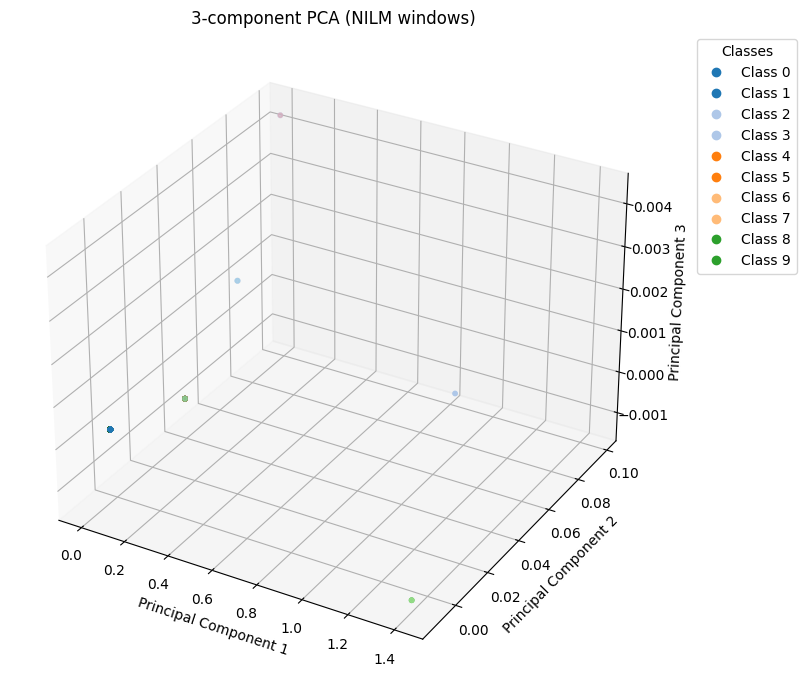

In [32]:
# =====================================
# Cell 9b – 3D PCA projection of windows
# =====================================
from mpl_toolkits.mplot3d import Axes3D  # 3D projection register করার জন্য

# 3D PCA (3 components)
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_sub)   # আগের Cell-9 এর X_sub, y_sub ব্যবহার করছি

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y_sub,
    s=10,
    cmap="tab20"
)

ax.set_title("3-component PCA (NILM windows)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

# ছোট একটা legend (class id অনুযায়ী)
# অনেক ক্লাস থাকলে সব না দেখিয়ে প্রথম কয়েকটা দেখাই
unique_classes = np.unique(y_sub)
max_legend = min(10, len(unique_classes))
handles = []
labels = []
for cid in unique_classes[:max_legend]:
    handles.append(
        plt.Line2D([0], [0], marker='o', linestyle='',
                   color=scatter.cmap(scatter.norm(cid)))
    )
    labels.append(f"Class {cid}")
ax.legend(handles, labels, title="Classes", loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()
